In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

In [2]:
imagem = Image.open("./meu_numero.jpeg").convert('L')

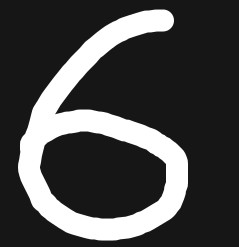

In [3]:
imagem

In [4]:
# Se a imagem tiver fundo preto (0), usamos o bbox direto:
bbox = imagem.getbbox()
if bbox:
    imagem_cortada = imagem.crop(bbox)
else:
    imagem_cortada = imagem

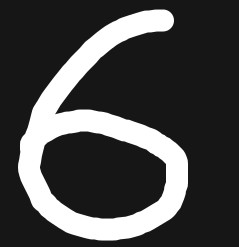

In [5]:
imagem_cortada

In [6]:
# Redimensionar o traço para no máximo 20x20, isso mantendo a proporção original
imagem_cortada.thumbnail((20, 20), Image.Resampling.LANCZOS)

In [7]:
# Criar uma tela preta de 28x28 e colar o traço no centro exato
imagem_final = Image.new('L', (28, 28), color=0)
pos_x = (28 - imagem_cortada.width) // 2
pos_y = (28 - imagem_cortada.height) // 2
imagem_final.paste(imagem_cortada, (pos_x, pos_y))

In [8]:
# Normalizar e preparar para o modelo
dados_imagem = np.array(imagem_final) / 255.0
dados_prontos = dados_imagem.reshape(1, 784)

In [13]:
dados_prontos

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

<br>

Nessa etapa vocês podem salvar o modelo de Machine learning ou rede neural, a partir do notebook correspondente, e importar para usar nessa previsão.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


print("Carregando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y
)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.1, random_state=42, stratify=y
# )

# Normalização: pixels variam de 0 a 255 lembram da aulas escalamos para o intervalo [0.0, 1.0]
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

modelo_mnist = Sequential([
    # Camada Oculta 1: 128 neurônios para aprender padrões dos 784 pixels
    Dense(128, activation='relu', input_shape=[784]), # note que a camada de entrada é definida quando passamos input_shape=[784]
    
    # Camada Oculta 2: 64 neurônios
    Dense(64, activation='relu'),
    
    # CAMADA DE SAÍDA MULTICLASSE:
    # 10 neurônios (um para cada dígito de 0 a 9) com ativação Softmax
    Dense(10, activation='softmax')
])

modelo_mnist.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # sparse_categorical_crossentropy é legal quando o nosso target y é número inteiro
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTreinando a Rede Neural no MNIST...")
historico = modelo_mnist.fit(
    X_train_scaled, y_train,
    validation_split=0.1,  # 10% do treino para validação a cada época
    epochs=10,   # 10 passadas completas
    batch_size=64,
    verbose=1 # Mostra uma barra de progresso
)

I0000 00:00:1788213241.809728    7631 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788213242.092197    7631 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788213243.148915    7631 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Carregando o dataset MNIST...


/home/flp/anaconda3/envs/venv_tf/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Treinando a Rede Neural no MNIST...
Epoch 1/10


W0000 00:00:1788213246.291416    7631 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 923us/step - accuracy: 0.9135 - loss: 0.3019 - val_accuracy: 0.9476 - val_loss: 0.1717
Epoch 2/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.9626 - loss: 0.1246 - val_accuracy: 0.9670 - val_loss: 0.1087
Epoch 3/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step - accuracy: 0.9747 - loss: 0.0843 - val_accuracy: 0.9699 - val_loss: 0.1010
Epoch 4/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 847us/step - accuracy: 0.9803 - loss: 0.0631 - val_accuracy: 0.9720 - val_loss: 0.0951
Epoch 5/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 845us/step - accuracy: 0.9846 - loss: 0.0483 - val_accuracy: 0.9730 - val_loss: 0.0915
Epoch 6/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 864us/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0.9764 - val_loss: 0.0845
Epoch 7/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 867us/step - accuracy: 0.9903 - loss: 0.0306 - val_accuracy: 0.9741 - val_loss: 0.0924
Epoch 8/10
739/739 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - accuracy: 0.9916 - loss: 0.0263 - val_accurac

In [10]:
# Predição
probabilidades = modelo_mnist.predict(dados_prontos)
predicao = np.argmax(probabilidades)
certeza = probabilidades[0][predicao] * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step



O modelo identificou o número: 6
Confiança: 99.46%



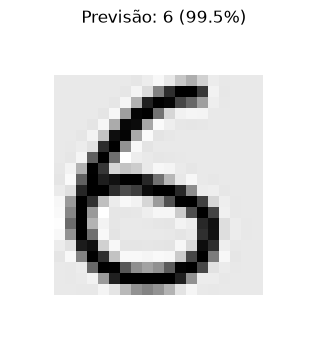

In [11]:
print(f"\nO modelo identificou o número: {predicao}")
print(f"Confiança: {certeza:.2f}%\n")

# 7. Visualizar a imagem centralizada como o MNIST espera
plt.figure(figsize=(4, 4))
plt.imshow(dados_imagem, cmap='binary')
plt.title(f"Previsão: {predicao} ({certeza:.1f}%)")
plt.axis('off')
plt.show()